In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams

%matplotlib inline

# --- PLOT STYLING CONFIGURATION ---
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# --- 1. ENVIRONMENT CONFIGURATION (To prevent ROOT errors) ---
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

# Set variables so functions_bonsai can locate required files
os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"

# --- 2. CUSTOM SCRIPT IMPORTS ---
sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

# -------------------------------
# LOAD PROCESSED DATA (PKL - FAST)
# -------------------------------

processed_folder = "/scratch/elena/9Li/results/run1848/processed"
processed_files = sorted(glob(f"{processed_folder}/*.pkl"))

print(f"Found {len(processed_files)} processed files.")

# ... (mantén tus imports y configuración de entorno igual)

if len(processed_files) > 0:
    # 1. GEOMETRY (UNCHANGED)
    geo_data = functions_bonsai.get_geo_mapping()
    lookup = functions_bonsai.build_lookup_table(geo_data)

    # 2. LOAD DATA
    dfs = [pd.read_pickle(f) for f in processed_files]
    df_all = pd.concat(dfs, ignore_index=True)

    print(f"Total clusters loaded: {len(df_all)}")

    # 3. QUALITY CHECK MEJORADO
    if 'chi2_ndof' in df_all.columns:
        # Solo calculamos la media de los que tuvieron éxito (no NaNs)
        valid_fits = df_all[df_all['fit_success'] == True]
        avg_chi2 = valid_fits['chi2_ndof'].mean()
        avg_rms = valid_fits['time_rms'].mean()
        print(f"Fits exitosos: {len(valid_fits)}")
        print(f"Average Chi2/NDoF: {avg_chi2:.2f}")
        print(f"Average Time RMS: {avg_rms:.2f} ns")

    # 4. APLICAR EL OFFSET FÍSICO (Lo que discutimos del Beam Pipe)
    # Creamos la columna global para que los plots salgan en 138cm y no en 0
    df_all['vertex_z_global'] = df_all['vertex_z'] + 138.0

Welcome to JupyROOT 6.26/04
Found 48 processed files.
Total clusters loaded: 661773
Fits exitosos: 651850
Average Chi2/NDoF: 28.16
Average Time RMS: 4.63 ns


In [2]:
df_all.head()

,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,vertex_x,vertex_y,vertex_z,fit_success,n_hits_used,time_rms,chi2,ndof,chi2_ndof,vertex_z_global
0,1.600714e+10,82126.521969,39,0,"[34, 32, 26, 26, 26, 23, 16, 16, 83, 83, 17, 9...","[78, 75, 60, 60, 60, 47, 73, 73, 28, 28, 29, 1...","[0, 7, 6, 10, 12, 9, 4, 13, 14, 0, 6, 11, 0, 7...","[17, 2, 8, 10, 4, 3, 1, 12, 13, 17, 8, 11, 17,...","[16007140414.384735, 16007140411.615402, 16007...","[106.0, 149.0, 103.0, 140.0, 190.0, 82.0, 109....",85.979150,73.280086,-42.152335,True,38,5.665656,1275.018077,34.0,37.500532,95.847665
1,1.600714e+10,85972.235668,25,0,"[16, 21, 21, 98, 47, 99, 99, 19, 1, 27, 11, 46...","[73, 64, 64, 100, 13, 90, 90, 41, 70, 2, 10, 4...","[3, 5, 15, 11, 16, 5, 8, 2, 7, 0, 8, 9, 2, 9, ...","[18, 7, 5, 11, 14, 7, 9, 0, 2, 17, 9, 3, 0, 3,...","[16007144267.85772, 16007144256.741348, 160071...","[97.0, 124.0, 74.0, 183.0, 137.0, 157.0, 219.0...",-140.736560,42.240332,-43.939386,True,25,1.673320,71.227766,21.0,3.391798,94.060614
2,1.600717e+10,111298.247068,39,0,"[26, 80, 80, 73, 44, 107, 99, 1, 22, 22, 14, 4...","[60, 30, 30, 31, 43, 44, 90, 70, 82, 82, 53, 7...","[5, 18, 2, 4, 15, 0, 17, 3, 1, 17, 18, 0, 2, 2...","[7, 16, 0, 1, 5, 17, 15, 18, 6, 15, 16, 17, 0,...","[16007169593.366247, 16007169587.131247, 16007...","[57.0, 83.0, 260.0, 182.0, 154.0, 134.0, 405.0...",15.615384,-26.430558,175.093384,True,35,2.557413,229.634306,31.0,7.407558,313.093384
3,1.600717e+10,113628.748404,39,0,"[26, 23, 16, 15, 73, 47, 99, 1, 87, 8, 8, 11, ...","[60, 47, 73, 58, 31, 13, 90, 70, 88, 84, 84, 1...","[14, 14, 3, 15, 12, 13, 4, 4, 3, 3, 6, 3, 11, ...","[13, 13, 18, 5, 4, 12, 1, 1, 18, 18, 8, 18, 11...","[16007171916.884207, 16007171917.886374, 16007...","[125.0, 138.0, 101.0, 109.0, 143.0, 350.0, 136...",-1.762201,-8.330375,57.483099,True,39,4.800459,925.755361,35.0,26.450153,195.483099
4,1.600719e+10,129177.227371,39,0,"[23, 16, 16, 16, 83, 103, 89, 111, 111, 111, 9...","[47, 73, 73, 73, 28, 98, 89, 97, 97, 97, 90, 9...","[3, 1, 17, 14, 11, 1, 18, 11, 7, 10, 2, 18, 1,...","[18, 6, 15, 13, 11, 6, 16, 11, 2, 10, 0, 16, 6...","[16007187464.494902, 16007187462.976036, 16007...","[169.0, 64.0, 63.0, 132.0, 122.0, 149.0, 186.0...",36.000164,-4.156596,-5.395753,True,38,4.775241,927.336219,34.0,27.274595,132.604247


In [4]:
def clean_hits(ids, times, charges):
    
    ids = np.array(ids)
    times = np.array(times)
    
    # ⚠️ FIX: charges puede no ser lista
    charges = np.array(charges) if isinstance(charges, (list, np.ndarray)) else np.zeros_like(ids)

    mask = ids >= 0

    return (
        ids[mask],
        times[mask],
        charges[mask] if len(charges) == len(ids) else charges
    )

all_data_mpmts = set()

for row in df_all.iloc[:100].itertuples():
    ids, times, charges = clean_hits(
        row.hit_slot_ids,
        row.hit_times_ns,
        row.hit_charges
    )
    
    all_data_mpmts.update(ids)

print([int(x) for x in sorted(list(all_data_mpmts))])

print("min ID:", min(all_data_mpmts))
print("max ID:", max(all_data_mpmts))
print("total unique:", len(all_data_mpmts))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 13, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 60, 61, 62, 64, 65, 66, 68, 69, 70, 71, 72, 73, 75, 76, 78, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 92, 93, 94, 95, 97, 98, 100, 101, 103, 104, 105]
min ID: 0
max ID: 105
total unique: 83


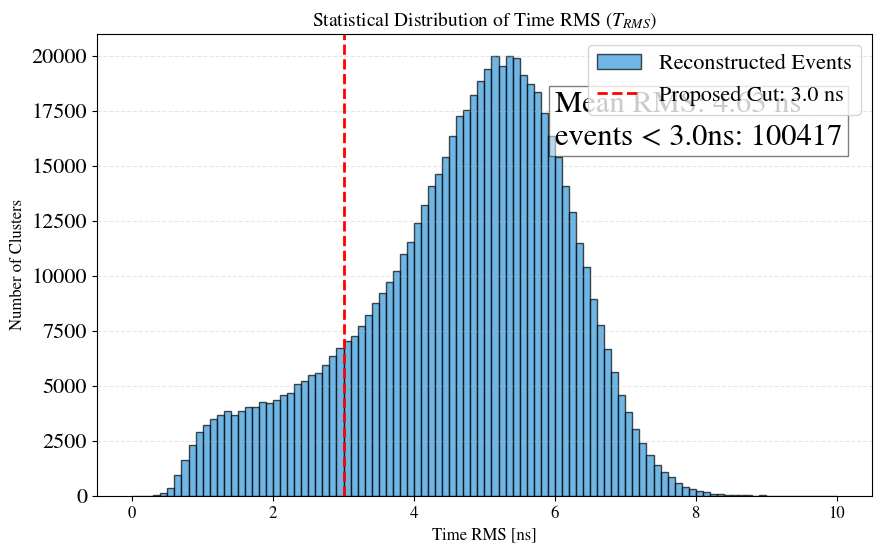

In [5]:
# --- 1. PREPARE DATA ---
# We only use events where the fit actually succeeded
rms_values = df_all[df_all['fit_success'] == True]['time_rms']

# --- 2. PLOT THE DISTRIBUTION ---
plt.figure(figsize=(10, 6))

# Histogram of RMS values
# We limit the range to 10 or 15 to see the 'peak' clearly
counts, bins, _ = plt.hist(rms_values, bins=100, range=[0, 10], 
                           color='#3498db', edgecolor='black', alpha=0.7, 
                           label='Reconstructed Events')

# --- 3. ANNOTATE THE CUT ---
# This is where you test your 3.0 ns or 2.5 ns threshold
current_cut = 3.0 
plt.axvline(current_cut, color='red', linestyle='--', linewidth=2, 
            label=f'Proposed Cut: {current_cut} ns')

# --- 4. FORMATTING ---
plt.title("Statistical Distribution of Time RMS ($T_{RMS}$)", fontsize=14)
plt.xlabel("Time RMS [ns]", fontsize=12)
plt.ylabel("Number of Clusters", fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend()

# Optional: Add a text box with statistics
mean_rms = np.mean(rms_values)
plt.text(6, max(counts)*0.8, f"Mean RMS: {mean_rms:.2f} ns\nevents < {current_cut}ns: {len(rms_values[rms_values < current_cut])}", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.show()

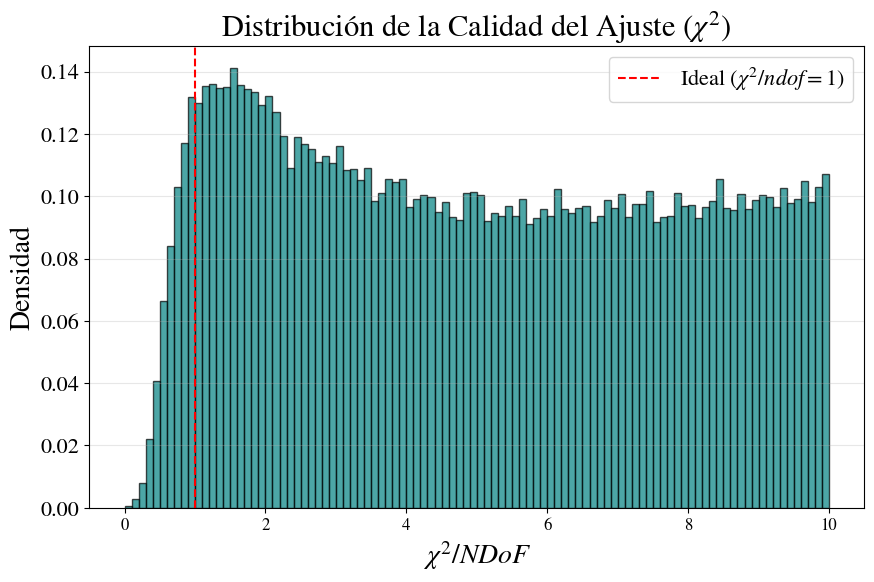

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(df_all['chi2_ndof'].dropna(), bins=100, range=(0, 10), 
         color='teal', alpha=0.7, edgecolor='black', density=True)

plt.axvline(1.0, color='red', linestyle='--', label="Ideal ($\chi^2/ndof=1$)")
plt.title("Distribución de la Calidad del Ajuste ($\chi^2$)", fontsize=22)
plt.xlabel("$\chi^2 / NDoF$")
plt.ylabel("Densidad")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

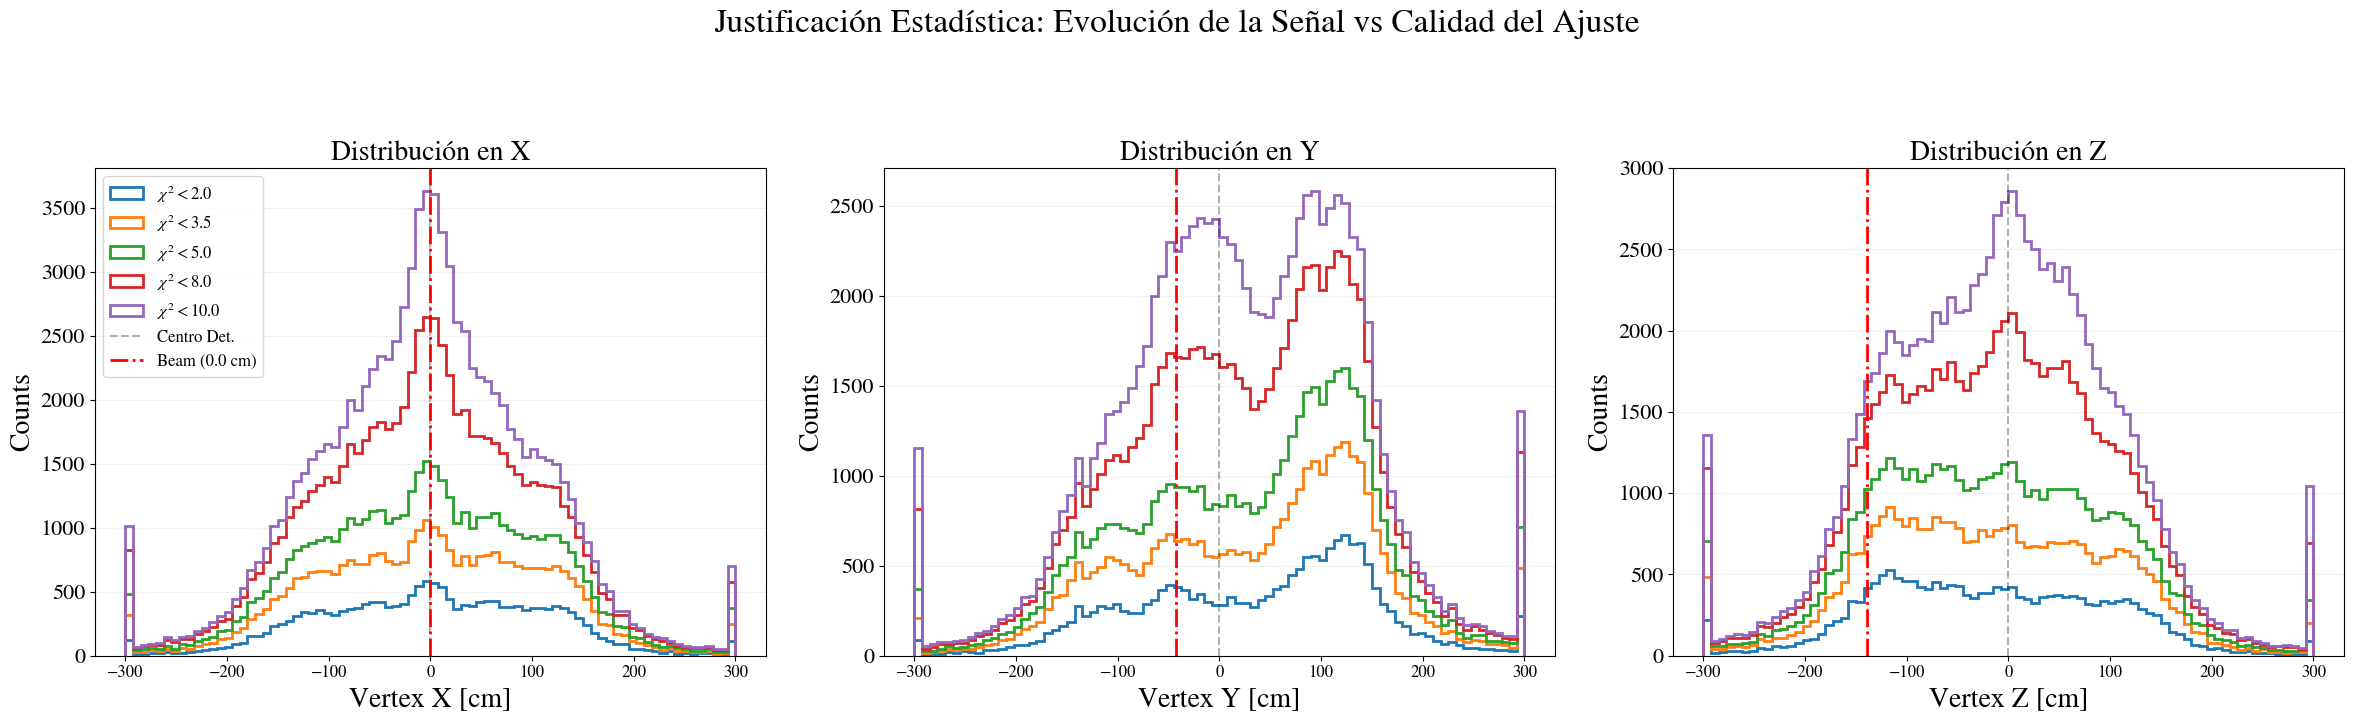

In [32]:
# 1. Configuración de coordenadas del Beam Pipe
# x=0, y=-42.47, z=-138.79
beam_coords = [0.0, -42.47, -138.79] 
coords_labels = ['vertex_x', 'vertex_y', 'vertex_z']
titles = ['Distribución en X', 'Distribución en Y', 'Distribución en Z']
axis_names = ['Vertex X [cm]', 'Vertex Y [cm]', 'Vertex Z [cm]']

# 2. Definición de cortes de calidad
cortes = [2.0, 3.5, 5.0, 8.0, 10.0]

# 3. Creación de los subplots
fig, axs = plt.subplots(1, 3, figsize=(24, 7))

for i, ax in enumerate(axs):
    # Iteramos sobre cada corte para ver la evolución
    for c in cortes:
        df_temp = df_all[df_all['chi2_ndof'] < c]
        
        # Graficamos el histograma para la coordenada actual (i)
        ax.hist(df_temp[coords_labels[i]], bins=80, range=(-300, 300), 
                histtype='step', linewidth=2, label=f'$\chi^2 < {c}$')

    # --- REFERENCIAS FÍSICAS ---
    # Marcamos el centro del detector (referencia de sesgo/bias)
    ax.axvline(0, color='black', linestyle='--', alpha=0.3, label='Centro Det.')
    
    # Marcamos la posición real del BEAM en esa coordenada específica
    ax.axvline(beam_coords[i], color='red', linestyle='-.', linewidth=2, 
               label=f'Beam ({beam_coords[i]} cm)')

    # Formateo de cada subplot
    ax.set_title(titles[i], fontsize=20)
    ax.set_xlabel(axis_names[i])
    ax.set_ylabel("Counts")
    ax.grid(axis='y', alpha=0.2)
    
    # Solo ponemos la leyenda en el primer plot para no saturar
    if i == 0:
        ax.legend(fontsize=12, loc='upper left')

plt.suptitle("Justificación Estadística: Evolución de la Señal vs Calidad del Ajuste", fontsize=24, y=1.05)
plt.tight_layout()
plt.show()

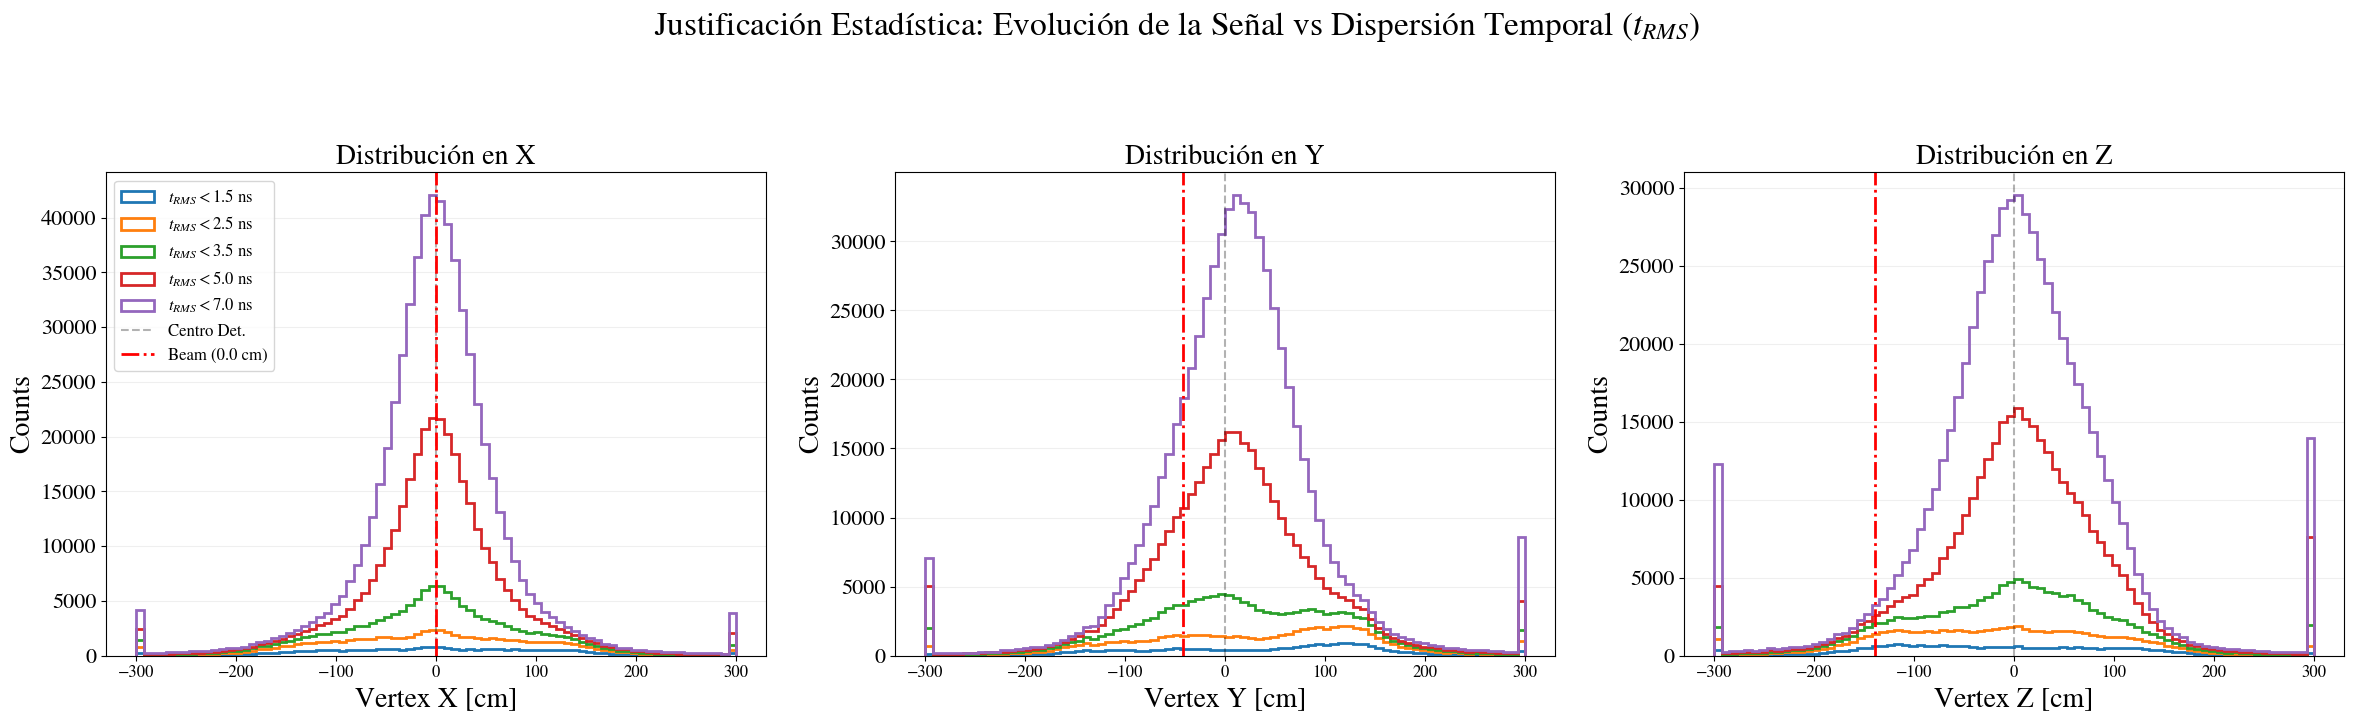

In [35]:
# 1. Configuración de coordenadas del Beam Pipe
beam_coords = [0.0, -42.47, -138.79] 
coords_labels = ['vertex_x', 'vertex_y', 'vertex_z']
titles = ['Distribución en X', 'Distribución en Y', 'Distribución en Z']
axis_names = ['Vertex X [cm]', 'Vertex Y [cm]', 'Vertex Z [cm]']

# 2. Definición de cortes de tRMS (en nanosegundos)
# Usamos valores basados en tu distribución previa (media ~4ns)
cortes_rms = [1.5, 2.5, 3.5, 5.0, 7.0]

# 3. Creación de los subplots
fig, axs = plt.subplots(1, 3, figsize=(24, 7))

for i, ax in enumerate(axs):
    # Solo consideramos ajustes que no fallaron catastróficamente
    df_valid = df_all[df_all['fit_success'] == True]
    
    for c in cortes_rms:
        # Filtramos por el valor de tRMS actual
        df_temp = df_valid[df_valid['time_rms'] < c]
        
        ax.hist(df_temp[coords_labels[i]], bins=80, range=(-300, 300), 
                histtype='step', linewidth=2, label=f'$t_{{RMS}} < {c}$ ns')

    # --- REFERENCIAS FÍSICAS ---
    ax.axvline(0, color='black', linestyle='--', alpha=0.3, label='Centro Det.')
    ax.axvline(beam_coords[i], color='red', linestyle='-.', linewidth=2, 
               label=f'Beam ({beam_coords[i]} cm)')

    ax.set_title(titles[i], fontsize=20)
    ax.set_xlabel(axis_names[i])
    ax.set_ylabel("Counts")
    ax.grid(axis='y', alpha=0.2)
    
    if i == 0:
        ax.legend(fontsize=12, loc='upper left')

plt.suptitle("Justificación Estadística: Evolución de la Señal vs Dispersión Temporal ($t_{RMS}$)", fontsize=24, y=1.05)
plt.tight_layout()
plt.show()

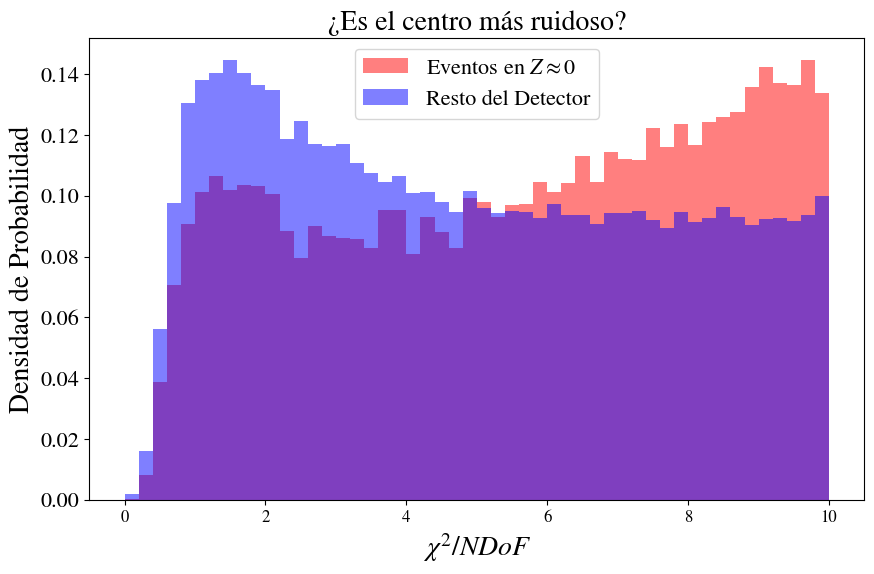

In [43]:
mask_centro = df_all['vertex_z'].abs() < 20.0 # Definimos "centro" como +/- 2cm

plt.figure(figsize=(10, 6))
plt.hist(df_all[mask_centro]['chi2_ndof'], bins=50, range=(0, 10), 
         density=True, alpha=0.5, label='Eventos en $Z \\approx 0$', color='red')
plt.hist(df_all[~mask_centro]['chi2_ndof'], bins=50, range=(0, 10), 
         density=True, alpha=0.5, label='Resto del Detector', color='blue')

plt.title("¿Es el centro más ruidoso?")
plt.xlabel("$\chi^2 / NDoF$")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.show()

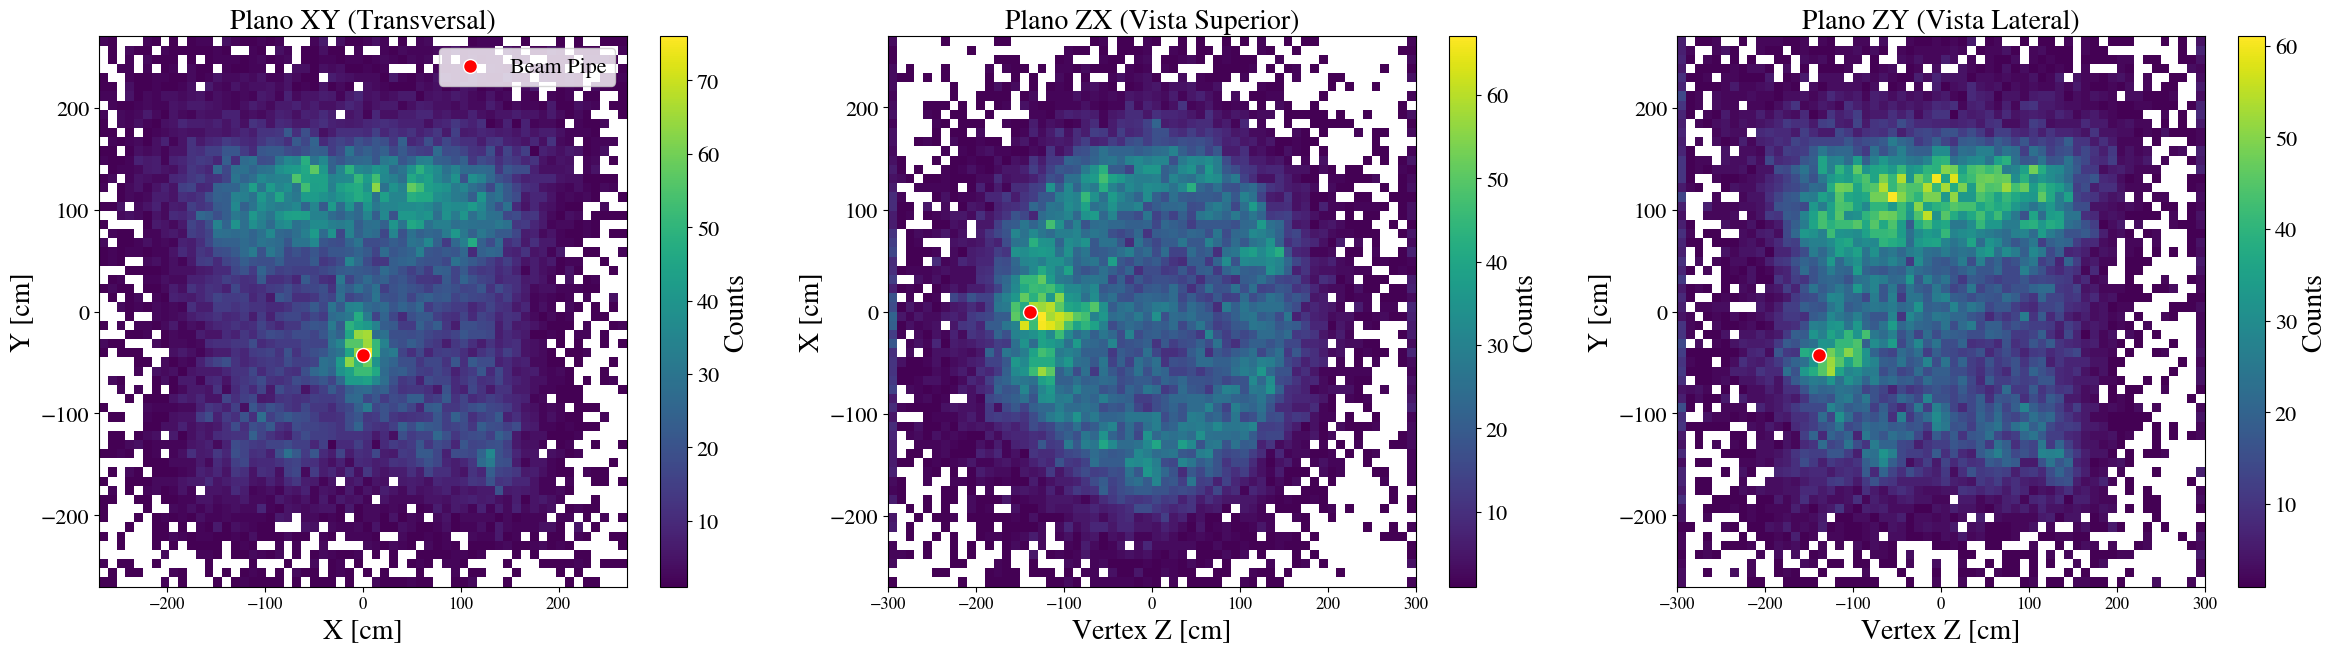

In [44]:
# 1. Filtro: Ajustes exitosos, calidad estadística y limpieza de artefactos
# Filtro optimizado: Éxito de ajuste, Calidad matemática Y Calidad temporal
mask = (df_all['fit_success'] == True) & \
       (df_all['chi2_ndof'] < 3.5) & \
       (df_all['time_rms'] < 3.0) & \
       (df_all['vertex_z'] != 0) & \
       (df_all['vertex_x'].abs() < 270) & \
       (df_all['vertex_y'].abs() < 270)

df_clean = df_all[mask].copy()

fig, axs = plt.subplots(1, 3, figsize=(24, 7))

# --- COORDENADAS REALES DEL BEAM PIPE ---
# Posición física proporcionada: x=0, y=-42.47 (vertical), z=138.79
beam_pipe = [0.0, -42.47, -138.79] 

# Plano XY (Transversal: X vs Y)
im0 = axs[0].hist2d(df_clean['vertex_x'], df_clean['vertex_y'], bins=60, cmap='viridis', cmin=1)
axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe')
axs[0].set_title("Plano XY (Transversal)")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
axs[0].legend(loc='upper right')
plt.colorbar(im0[3], ax=axs[0], label='Counts')

# Plano ZX (Vista Superior: Z vs X)
im1 = axs[1].hist2d(df_clean['vertex_z'], df_clean['vertex_x'], bins=60, cmap='viridis', cmin=1)
axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white')
axs[1].set_title("Plano ZX (Vista Superior)")
axs[1].set_xlabel("Vertex Z [cm]")
axs[1].set_ylabel("X [cm]")
plt.colorbar(im1[3], ax=axs[1], label='Counts')

# Plano ZY (Vista Lateral: Z vs Y)
im2 = axs[2].hist2d(df_clean['vertex_z'], df_clean['vertex_y'], bins=60, cmap='viridis', cmin=1)
axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white')
axs[2].set_title("Plano ZY (Vista Lateral)")
axs[2].set_xlabel("Vertex Z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(im2[3], ax=axs[2], label='Counts')

plt.tight_layout()
plt.show()

In [6]:
# Convert nanoseconds to milliseconds
df_all['t_window_start_rel_ms'] = df_all['t_window_start_rel_ns'] / 1e6

# Filter for successful fits to ensure tRMS and Chi2 values are meaningful
# Adjust t_rms < 15 if you want to see a wider or narrower range
mask = df_all['fit_success'] == True
df_filtered = df_all[mask]

print(f"Events ready for plotting: {len(df_filtered)}")

Events ready for plotting: 651850


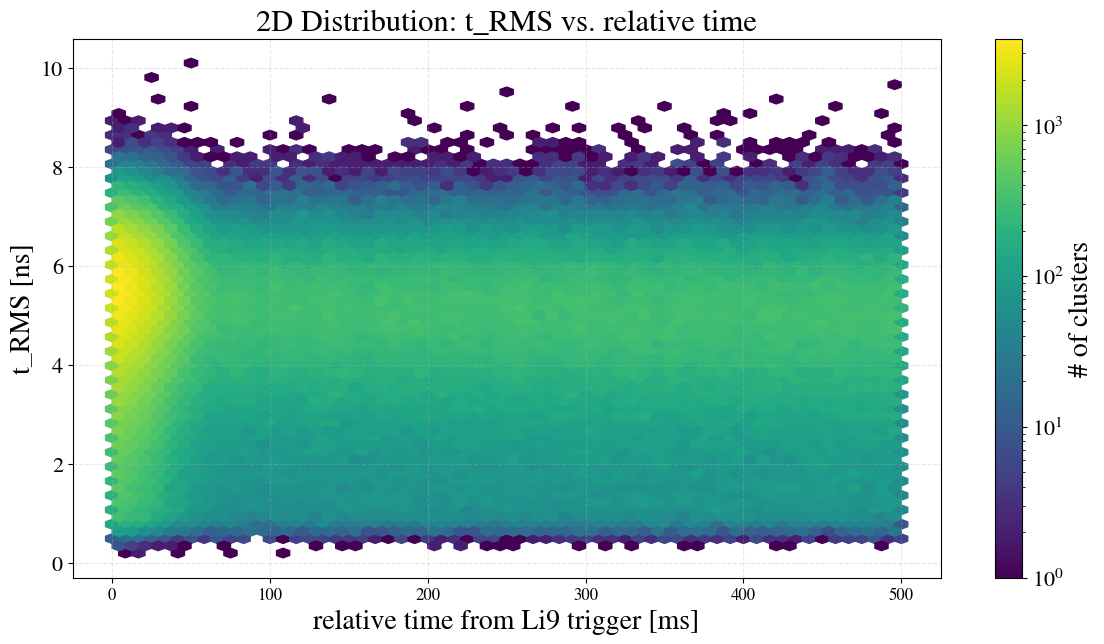

In [7]:
plt.figure(figsize=(14, 7))

# We use hexbin with log scaling to handle high density near t=0
hb = plt.hexbin(df_filtered['t_window_start_rel_ms'], 
                df_filtered['time_rms'], 
                gridsize=60, cmap='viridis', bins='log')

cb = plt.colorbar(hb)
cb.set_label('# of clusters')
plt.title('2D Distribution: t_RMS vs. relative time', fontsize=22)
plt.xlabel('relative time from Li9 trigger [ms]', fontsize=20)
plt.ylabel("t_RMS [ns]", fontsize=20)
plt.grid(alpha=0.3, linestyle='--')

plt.show()

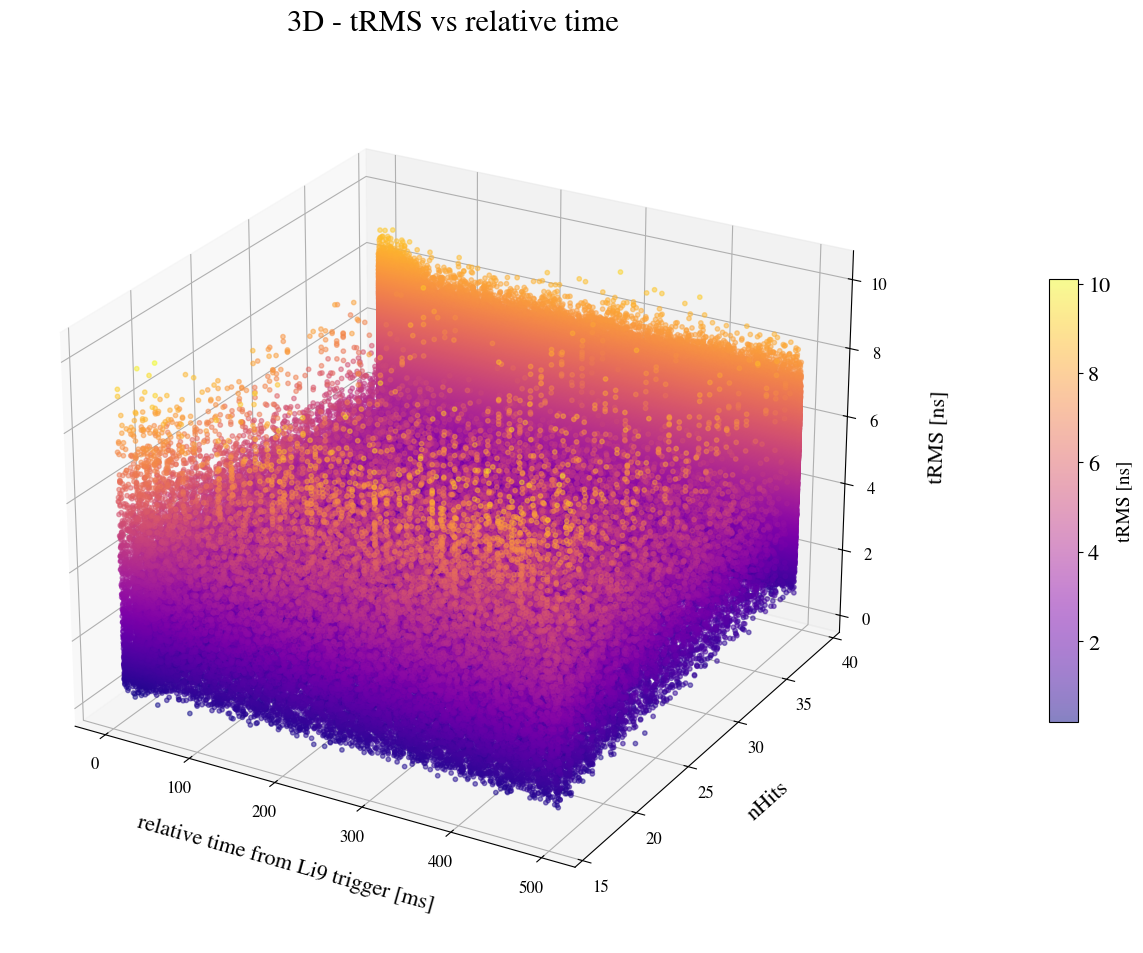

In [8]:
# --- 2. 3D PLOTTING ---
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

# Using the correct column names from your list: 
# 't_window_start_rel_ms' (created), 'nHits' (capital H), 'time_rms'
plot_sample = df_filtered

scatter = ax.scatter(plot_sample['t_window_start_rel_ms'], 
                     plot_sample['nHits'], 
                     plot_sample['time_rms'], 
                     c=plot_sample['time_rms'], 
                     cmap='plasma', 
                     alpha=0.5, 
                     s=10)

# Labels and Formatting
ax.set_xlabel('relative time from Li9 trigger [ms]', fontsize=16, labelpad=15)
ax.set_ylabel('nHits', fontsize=16, labelpad=15)
ax.set_zlabel('\ntRMS [ns]', fontsize=16, labelpad=15)
ax.set_title('3D - tRMS vs relative time', fontsize=22, pad=20)

# Colorbar for the tRMS dimension
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=15, pad=0.1)
cbar.set_label('tRMS [ns]', fontsize=14)

# Adjusting the view to see the 9Li decay profile clearly (Time vs nHits)
ax.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.show()

In [9]:
# 1. Filter for successful fits and high quality (Karlen Cut)
# We use 3.0 ns as a standard 'clean' cut for this detector
df_success = df_all[df_all['fit_success'] == True].copy()
df_clean = df_success[df_success['time_rms'] < 2.2].copy()

print(f"Clusters with successful reconstruction: {len(df_success)}")
print(f"High-quality clusters (RMS < 3ns): {len(df_clean)}")

Clusters with successful reconstruction: 651850
High-quality clusters (RMS < 3ns): 55415


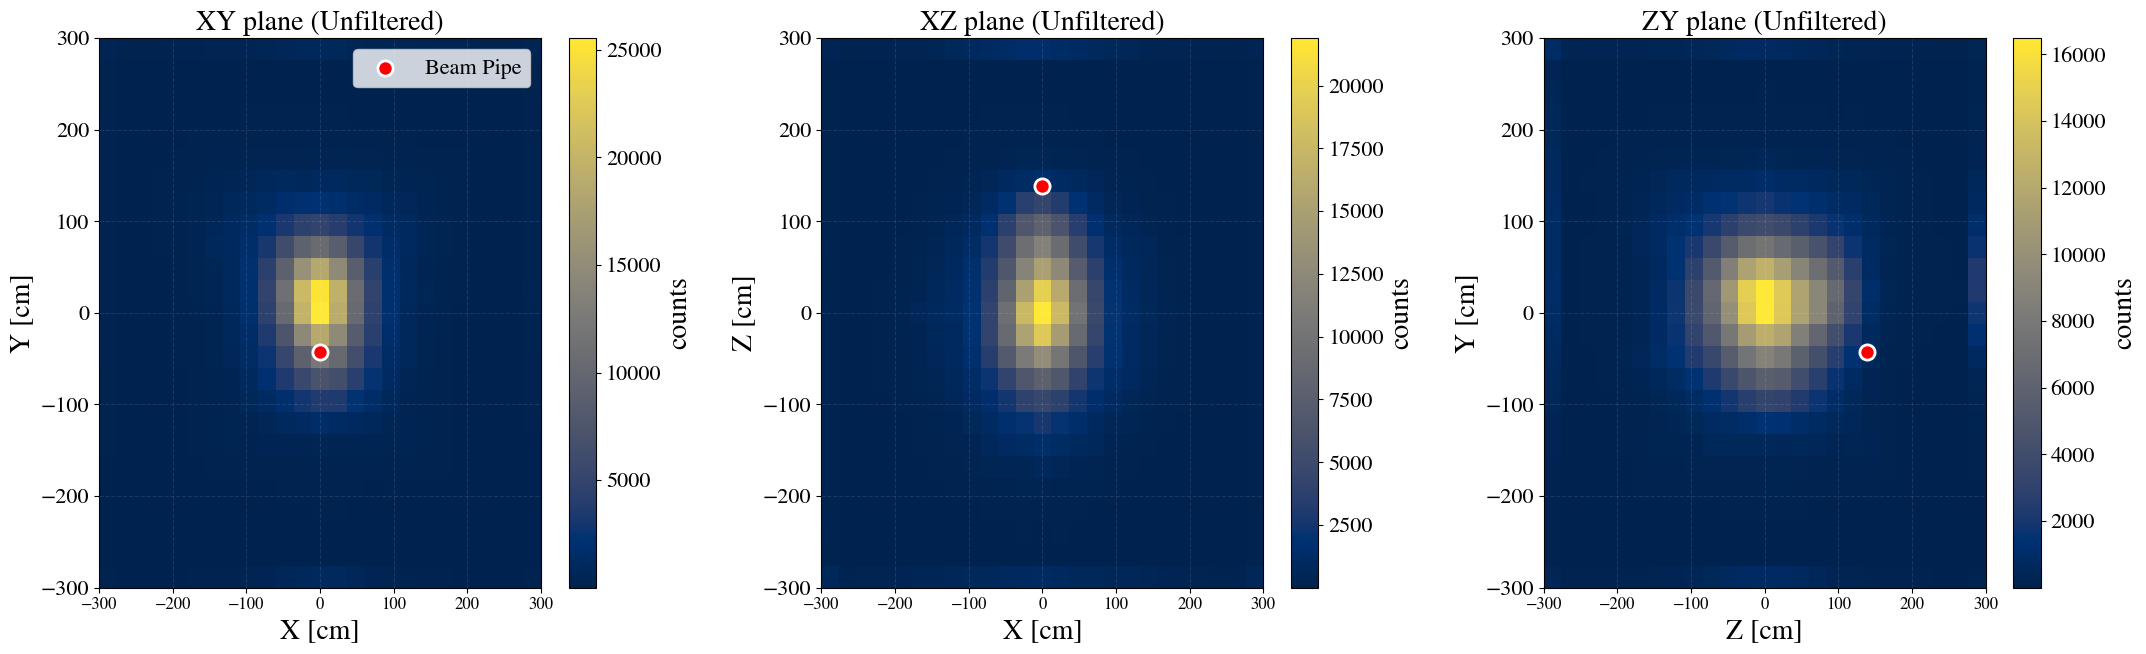

Total reconstructed clusters plotted: 651850


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA PREPARATION (RAW) ---
# We only filter for successful fits to ensure coordinates exist, 
# but we do NOT apply the Karlen Cut (RMS)
df_all_fits = df_all[df_all['fit_success'] == True].copy()

x_raw = df_all_fits["vertex_x"]
y_raw = df_all_fits["vertex_y"]
z_raw = df_all_fits["vertex_z"]

# --- 2. PLOT CONFIGURATION ---
fig, axs = plt.subplots(1, 3, figsize=(22, 7))

# Beam pipe target coordinates [x, y, z]
beam = np.array([0.0, -42.47, 138.79])

# Settings: Full volume view with 25 bins
BINS = 25 
LIMIT = 300 

# --- XY PLANE (FRONT VIEW) ---
h1 = axs[0].hist2d(x_raw, y_raw, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[0].scatter(beam[0], beam[1], color="red", s=120, label="Beam Pipe", edgecolors="white", linewidth=2, zorder=10)
axs[0].set_title("XY plane (Unfiltered)")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
plt.colorbar(h1[3], ax=axs[0], label="counts")

# --- XZ PLANE (TOP VIEW) ---
h2 = axs[1].hist2d(x_raw, z_raw, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[1].scatter(beam[0], beam[2], color="red", s=120, edgecolors="white", linewidth=2, zorder=10)
axs[1].set_title("XZ plane (Unfiltered)")
axs[1].set_xlabel("X [cm]")
axs[1].set_ylabel("Z [cm]")
plt.colorbar(h2[3], ax=axs[1], label="counts")

# --- ZY PLANE (SIDE VIEW) ---
h3 = axs[2].hist2d(z_raw, y_raw, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[2].scatter(beam[2], beam[1], color="red", s=120, edgecolors="white", linewidth=2, zorder=10)
axs[2].set_title("ZY plane (Unfiltered)")
axs[2].set_xlabel("Z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(h3[3], ax=axs[2], label="counts")

# --- AESTHETICS ---
for ax in axs:
    ax.set_facecolor('#000033') 
    ax.grid(color='white', alpha=0.1, linestyle='--')

axs[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Total reconstructed clusters plotted: {len(df_all_fits)}")

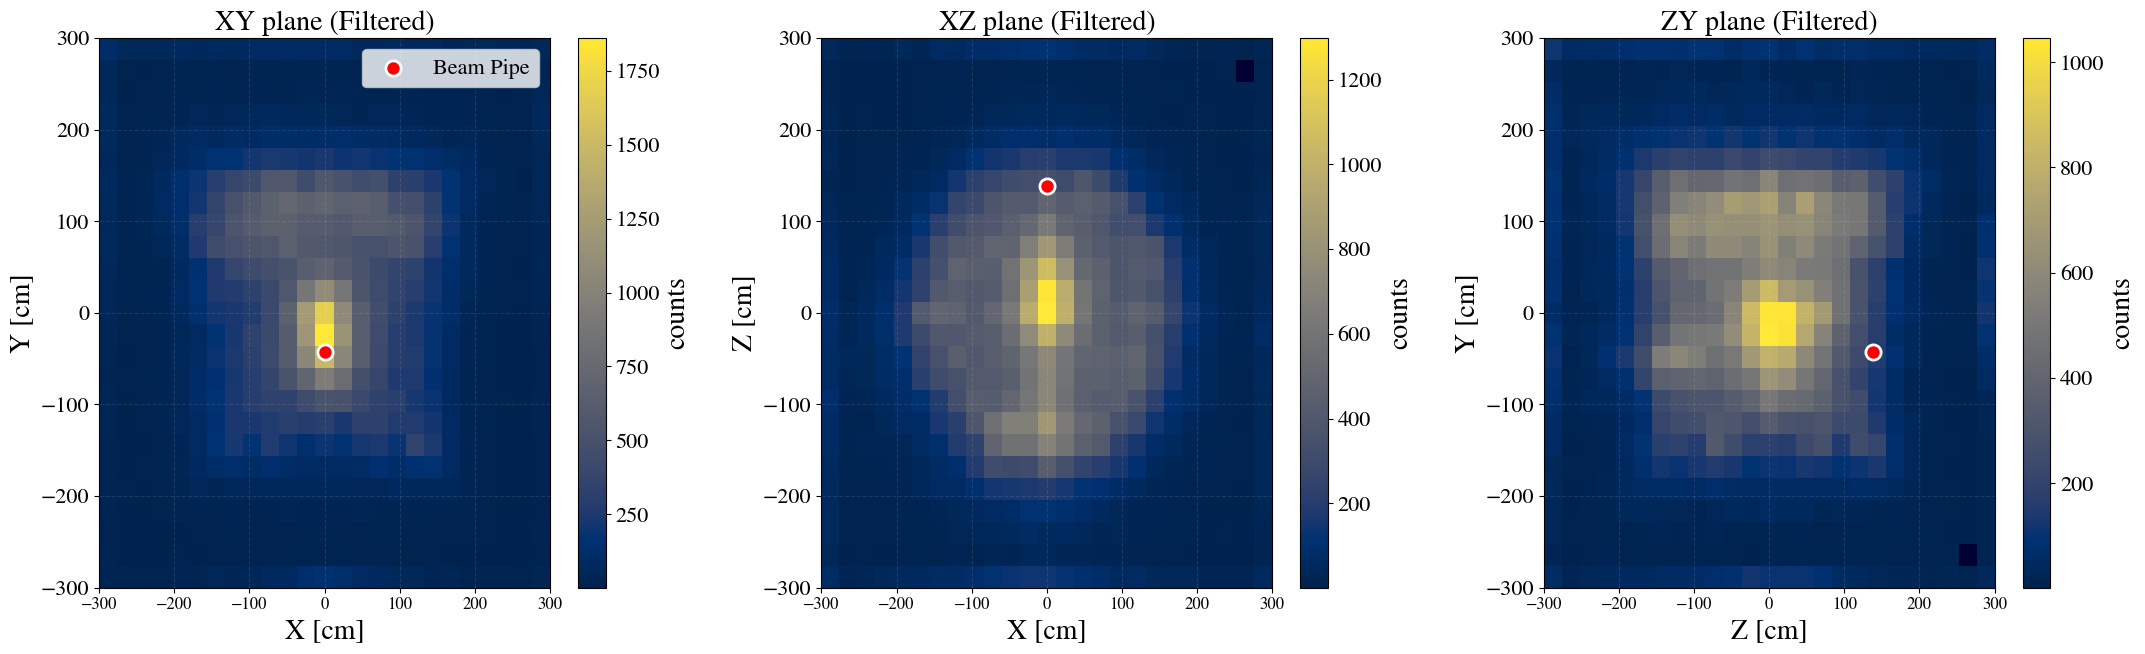

Total high-quality events plotted: 100417


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA PREPARATION (FILTERED) ---
# Filtering for success and the Karlen Cut (RMS < 3.0 ns)
karlen_cut = 3.0
df_clean = df_all[(df_all['fit_success'] == True) & (df_all['time_rms'] < karlen_cut)].copy()

x_f = df_clean["vertex_x"]
y_f = df_clean["vertex_y"]
z_f = df_clean["vertex_z"]

# --- 2. PLOT CONFIGURATION ---
fig, axs = plt.subplots(1, 3, figsize=(22, 7))

# Beam pipe target coordinates [x, y, z]
beam = np.array([0.0, -42.47, 138.79])

# Settings: Full volume view with 25 bins
BINS = 25 
LIMIT = 300 

# --- XY PLANE (FRONT VIEW) ---
h1 = axs[0].hist2d(x_f, y_f, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[0].scatter(beam[0], beam[1], color="red", s=120, label="Beam Pipe", edgecolors="white", linewidth=2, zorder=10)
axs[0].set_title("XY plane (Filtered)")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
plt.colorbar(h1[3], ax=axs[0], label="counts")

# --- XZ PLANE (TOP VIEW) ---
h2 = axs[1].hist2d(x_f, z_f, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[1].scatter(beam[0], beam[2], color="red", s=120, edgecolors="white", linewidth=2, zorder=10)
axs[1].set_title("XZ plane (Filtered)")
axs[1].set_xlabel("X [cm]")
axs[1].set_ylabel("Z [cm]")
plt.colorbar(h2[3], ax=axs[1], label="counts")

# --- ZY PLANE (SIDE VIEW) ---
# Corrected: Now strictly using z_f and y_f
h3 = axs[2].hist2d(z_f, y_f, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[2].scatter(beam[2], beam[1], color="red", s=120, edgecolors="white", linewidth=2, zorder=10)
axs[2].set_title("ZY plane (Filtered)")
axs[2].set_xlabel("Z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(h3[3], ax=axs[2], label="counts")

# --- AESTHETICS ---
for ax in axs:
    ax.set_facecolor('#000033') 
    ax.grid(color='white', alpha=0.1, linestyle='--')

axs[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Total high-quality events plotted: {len(df_clean)}")

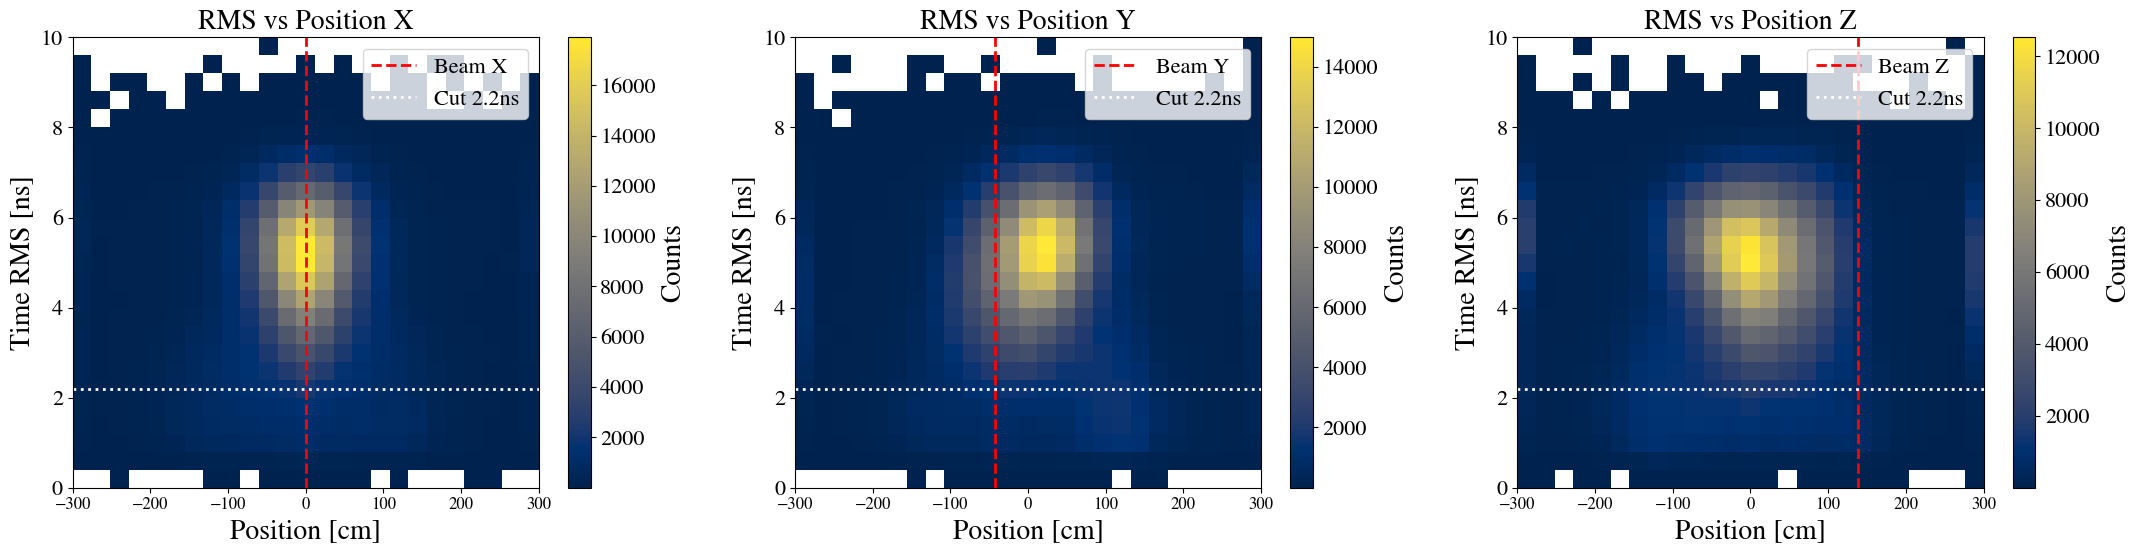

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA PREPARATION ---
df_diag = df_all[df_all['fit_success'] == True].copy()
beam = np.array([0.0, -42.47, 138.79])
OPTIMAL_CUT = 2.2

# --- 2. PLOT CONFIGURATION ---
fig, axs = plt.subplots(1, 3, figsize=(22, 6))
BINS = 25
RMS_LIMIT = 10 
POS_LIMIT = 300

# Subplot 1: RMS vs X
h1 = axs[0].hist2d(df_diag['vertex_x'], df_diag['time_rms'], bins=BINS, 
                   range=[[-POS_LIMIT, POS_LIMIT], [0, RMS_LIMIT]], cmap='cividis', cmin=1)
axs[0].axvline(beam[0], color='red', linestyle='--', linewidth=2, label='Beam X')
axs[0].set_title('RMS vs Position X')

# Subplot 2: RMS vs Y
h2 = axs[1].hist2d(df_diag['vertex_y'], df_diag['time_rms'], bins=BINS, 
                   range=[[-POS_LIMIT, POS_LIMIT], [0, RMS_LIMIT]], cmap='cividis', cmin=1)
axs[1].axvline(beam[1], color='red', linestyle='--', linewidth=2, label='Beam Y')
axs[1].set_title('RMS vs Position Y')

# Subplot 3: RMS vs Z
h3 = axs[2].hist2d(df_diag['vertex_z'], df_diag['time_rms'], bins=BINS, 
                   range=[[-POS_LIMIT, POS_LIMIT], [0, RMS_LIMIT]], cmap='cividis', cmin=1)
axs[2].axvline(beam[2], color='red', linestyle='--', linewidth=2, label='Beam Z')
axs[2].set_title('RMS vs Position Z')

# Aesthetics and Threshold marker
for i, ax in enumerate(axs):
    ax.axhline(OPTIMAL_CUT, color='white', linestyle=':', linewidth=2, label=f'Cut {OPTIMAL_CUT}ns')
    ax.set_xlabel('Position [cm]')
    ax.set_ylabel('Time RMS [ns]')
    ax.legend(loc='upper right')
    plt.colorbar([h1, h2, h3][i][3], ax=ax, label='Counts')

plt.tight_layout()
plt.show()

In [ ]:
def test_cuts_3d(cut_list):
    # Beam pipe target coordinates
    beam_x, beam_y, beam_z = 0.0, -42.47, 138.79
    
    results = []
    print(f"{'Cut [ns]':<10} | {'Events':<8} | {'Err X [cm]':<12} | {'Err Y [cm]':<12} | {'Err Z [cm]':<12}")
    print("-" * 65)

    for c in cut_list:
        # Filter by success and RMS threshold
        subset = df_all[(df_all['fit_success'] == True) & (df_all['time_rms'] < c)]
        
        if len(subset) == 0:
            continue

        # Mean Absolute Error (MAE) for each axis
        err_x = np.mean(np.abs(subset['vertex_x'] - beam_x))
        err_y = np.mean(np.abs(subset['vertex_y'] - beam_y))
        err_z = np.mean(np.abs(subset['vertex_z'] - beam_z))
        
        results.append({
            'cut': c, 
            'n_events': len(subset), 
            'err_x': err_x, 
            'err_y': err_y, 
            'err_z': err_z
        })
        
        print(f"{c:<10} | {len(subset):<8} | {err_x:<12.2f} | {err_y:<12.2f} | {err_z:<12.2f}")
    
    return pd.DataFrame(results)

# Execute the test
cut_results = test_cuts_3d([3.5, 3.3, 3.0, 2.7, 2.5, 2.2, 2.0, 1.7, 1.5, 1.3, 1.0])

Cut [ns]   | Events   | Err X [cm]   | Err Y [cm]   | Err Z [cm]  
-----------------------------------------------------------------
3.5        | 139378   | 73.23        | 96.13        | 153.20      
3.3        | 122394   | 76.20        | 99.52        | 155.50      
3.0        | 100417   | 80.37        | 104.52       | 158.92      
2.7        | 81405    | 84.16        | 109.54       | 162.14      
2.5        | 70331    | 86.13        | 112.37       | 163.90      
2.2        | 55415    | 88.50        | 115.54       | 165.61      
2.0        | 46451    | 89.44        | 117.15       | 165.94      
1.7        | 33971    | 89.75        | 118.34       | 165.77      
1.5        | 26091    | 89.18        | 118.38       | 165.54      
1.3        | 18590    | 87.78        | 117.46       | 165.61      
1.0        | 8242     | 83.15        | 113.56       | 167.92      


In [ ]:
# =========================
# Chi2 reconstruction metric
# =========================

def compute_chi2(row):
    """
    Approximate chi2 from multilateration residuals.
    Uses stored optimization residual proxy.
    """
    try:
        # time_rms is std of residuals -> approximate chi2
        # chi2 ~ N * rms^2
        n = row['n_hits_used']
        rms = row['time_rms']
        return n * (rms ** 2)
    except:
        return np.nan


df_all['chi2'] = df_all.apply(compute_chi2, axis=1)

print("Chi2 computed.")
print(df_all['chi2'].describe())

Chi2 computed.
count    651850.000000
mean        845.347384
std         461.116673
min           0.281483
25%         502.614363
50%         860.009796
75%        1169.354771
max        3318.386544
Name: chi2, dtype: float64
